# 1. Alinha a escala da visão com o Ground Truth e salva a nova trajetória corrigida
evo_traj tum /home/aki/Desktop/GitHub/Python-VO/results/cusco_dataset_1/cusco_dataset_1_vo_SIFT_FLANN_nopnp.txt --ref /home/aki/Desktop/GitHub/Python-VO/results/cusco_dataset_1/cusco_dataset_1_gt_SIFT_FLANN_nopnp.txt -a -s --save_as_tum

# 2. Avalia todo mundo junto sem aplicar nova escala para ser justo com as rodas
evo_ape kitti home/aki/Desktop/GitHub/Python-VO/results/cusco_dataset_1/cusco_dataset_1_gt_SIFT_FLANN_nopnp.txt cusco_dataset_1_gt_SIFT_FLANN_nopnp.kitti.txt -a --plot

In [3]:
import os
import subprocess
import re
import pandas as pd
from IPython.display import Image, display



# ==========================================
# 2. Funções Auxiliares para o evo
# ==========================================
def extract_rmse_from_ape(gt_path, est_path, apply_scale=True):
    """Roda o evo_ape e extrai o valor do RMSE (ATE) via Regex."""
    if not os.path.exists(est_path):
        return None
        
    cmd = ["evo_ape", "tum", gt_path, est_path, "-a"]
    if apply_scale:
        cmd.append("-s") # Adiciona alinhamento de escala (Sim(3))
        
    result = subprocess.run(cmd, capture_output=True, text=True)
    match = re.search(r"rmse\s+(\d+\.\d+)", result.stdout)
    if match:
        return float(match.group(1))
    return None

def extract_rmse_from_rpe(gt_path, est_path, apply_scale=True):
    """Roda o evo_rpe e extrai o valor do RMSE (RPE) via Regex."""
    if not os.path.exists(est_path):
        return None
        
    # evo_rpe mede o erro relativo (delta)
    cmd = ["evo_rpe", "tum", gt_path, est_path, "-a"]
    if apply_scale:
        cmd.append("-s")
        
    result = subprocess.run(cmd, capture_output=True, text=True)
    match = re.search(r"rmse\s+(\d+\.\d+)", result.stdout)
    if match:
        return float(match.group(1))
    return None

def plot_combined_trajectories(gt_path, est_dict, output_name):
    """
    Usa o evo_traj para plotar múltiplas trajetórias na mesma imagem,
    todas alinhadas ao Ground Truth.
    """
    arquivo_plot = f"{output_name}.png"
    
    # overwrite manual
    if os.path.exists(arquivo_plot):
        os.remove(arquivo_plot)
        
    # Prepara o comando base
    cmd = ["evo_traj", "tum"]
    
    # Adiciona os arquivos que serão avaliados
    for est_path in est_dict.values():
        cmd.append(est_path)
        
    # Adiciona as opções de referência, alinhamento e nomenclatura
    cmd.extend([
        "--ref", gt_path,
        "-a", "-s", "--plot_mode", "xz", 
        "--save_plot", output_name,
    ])
    ambiente_modificado = os.environ.copy()
    ambiente_modificado["MPLBACKEND"] = "Agg"
        
    print(f"Gerando gráfico comparativo: {arquivo_plot} ...")
    subprocess.run(cmd, env=ambiente_modificado)




In [4]:
# ==========================================
# 1. Configurações Iniciais
# ==========================================
# Caminho onde os seus arquivos .txt (formato TUM) estão salvos
BASE_DIR = "/home/aki/Desktop/GitHub/Python-VO/results"

# Definição dos testes que você rodou"00", 
datasets = ["urban27"]#"cusco_dataset_1", "cusco_dataset_2"]
descriptors = ["SIFT", "XFEAT", "SUPERPOINT", "ORB"]
matchers = ["FLANN", "LIGHT", "KNN"]
suffixes = ["nopnp"] # Ex: "", "ba", "nopnp"

Iniciando avaliação em lote com o pacote EVO...

Analisando Dataset: urban27
Avaliando Odometria Visual: SIFT + FLANN
Avaliando Odometria Visual: SIFT + LIGHT
Avaliando Odometria Visual: XFEAT + FLANN
Avaliando Odometria Visual: XFEAT + LIGHT
Avaliando Odometria Visual: SUPERPOINT + FLANN
Avaliando Odometria de Roda (WO) pela primeira e única vez...
Avaliando Odometria Visual: SUPERPOINT + LIGHT
  [ALERTA] Trajetória inválida/corrompida. Ignorada do plot: /home/aki/Desktop/GitHub/Python-VO/results/urban27/urban27_vo_SUPERPOINT_LIGHT_nopnp.txt
Avaliando Odometria Visual: ORB + KNN
Gerando gráfico comparativo: /home/aki/Desktop/GitHub/Python-VO/results/urban27/comparativo_trajetorias_urban27.png ...
--------------------------------------------------------------------------------
name:	urban27_vo_SIFT_FLANN_nopnp
infos:	11605 poses, 9581.708m path length, 1160.412s duration
--------------------------------------------------------------------------------
name:	urban27_vo_SIFT_LIGHT_nopnp
i

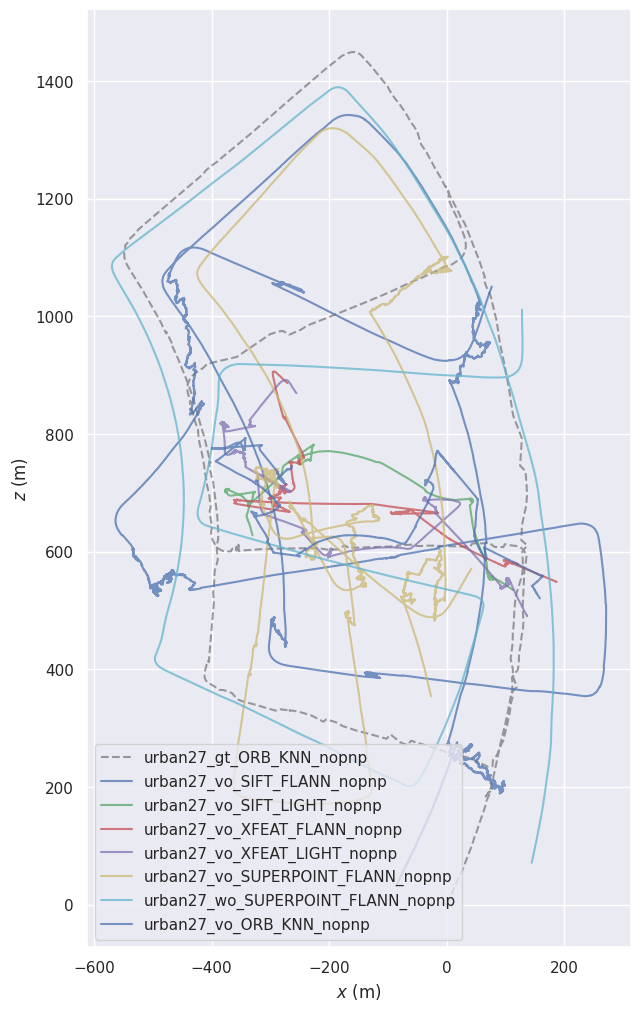


RANKING FINAL DE DESEMPENHO (Baseado no evo_ape e evo_rpe)
Dataset       Configuração  ATE VO (m)  RPE VO (m) ATE WO (m) RPE WO (m) ATE BA (m) RPE BA (m)
urban27       SIFT + FLANN    126.9238      1.0914        N/A        N/A        N/A        N/A
urban27 SUPERPOINT + FLANN    292.5699      0.9897    95.7468     0.8567        N/A        N/A
urban27      XFEAT + LIGHT    356.6149      0.8304        N/A        N/A        N/A        N/A
urban27          ORB + KNN    357.0242      0.8367        N/A        N/A        N/A        N/A
urban27       SIFT + LIGHT    365.9135      0.8264        N/A        N/A        N/A        N/A
urban27      XFEAT + FLANN    368.3962      0.8381        N/A        N/A        N/A        N/A

Tabela exportada para: /home/aki/Desktop/GitHub/Python-VO/results/tabela_resultados_finais.csv


In [5]:
# ==========================================
# 3. Pipeline Principal de Avaliação
# ==========================================
print("Iniciando avaliação em lote com o pacote EVO...\n")
resultados = []

for dataset in datasets:
    print(f"{'='*50}\nAnalisando Dataset: {dataset}\n{'='*50}")
    work_dir = os.path.join(BASE_DIR, dataset)
    
    trajetorias_para_plot = {}
    
    # ----------------------------------------------------
    # FLAGS PARA GARANTIR QUE A WO SEJA AVALIADA SÓ UMA VEZ
    # ----------------------------------------------------
    wo_ja_avaliada = False
    kitti_ja_avisado = False
    global_ate_wo = "N/A"
    global_rpe_wo = "N/A"
    
    for desc in descriptors:
        for matcher in matchers:
            for suffix in suffixes:
                suf_str = f"_{suffix}" if suffix else ""
                
                gt_file = os.path.join(work_dir, f"{dataset}_gt_{desc}_{matcher}{suf_str}.txt")
                vo_file = os.path.join(work_dir, f"{dataset}_vo_{desc}_{matcher}{suf_str}.txt")
                wo_file = os.path.join(work_dir, f"{dataset}_wo_{desc}_{matcher}{suf_str}.txt")
                ba_file = os.path.join(work_dir, f"{dataset}_ba_{desc}_{matcher}{suf_str}.txt")
                
                if not os.path.exists(gt_file) or not os.path.exists(vo_file):
                    continue
                
                nome_config = f"{desc} + {matcher}"
                print(f"Avaliando Odometria Visual: {nome_config}")
                
                # --- 1. AVALIAÇÃO DA ODOMETRIA VISUAL (VO) ---
                ate_vo = extract_rmse_from_ape(gt_file, vo_file, apply_scale=True)
                rpe_vo = extract_rmse_from_rpe(gt_file, vo_file, apply_scale=True)
                
                # Só adiciona no dicionário de plotagem se o EVO conseguiu processar a VO (Evita o erro Umeyama)
                if ate_vo is not None:
                    trajetorias_para_plot[f"VO ({nome_config})"] = vo_file
                else:
                    print(f"  [ALERTA] Trajetória inválida/corrompida. Ignorada do plot: {vo_file}")
                
                # --- 2. AVALIAÇÃO DA ODOMETRIA DE RODA (WO) ---
                ate_wo = "N/A"
                rpe_wo = "N/A"
                
                if "kitti" not in dataset.lower():
                    if os.path.exists(wo_file):
                        # Se ainda não foi avaliada, calcula agora
                        if not wo_ja_avaliada:
                            print("Avaliando Odometria de Roda (WO) pela primeira e única vez...")
                            global_ate_wo = extract_rmse_from_ape(gt_file, wo_file, apply_scale=False) 
                            global_rpe_wo = extract_rmse_from_rpe(gt_file, wo_file, apply_scale=False) 
                            
                            # Adiciona ao dicionário de trajetórias (vai aparecer 1 vez só no gráfico)
                            trajetorias_para_plot["Wheel Odometry"] = wo_file
                            wo_ja_avaliada = True
                        
                        # Reusa os valores já calculados para manter a tabela completa
                        ate_wo = global_ate_wo
                        rpe_wo = global_rpe_wo
                else:
                    if not kitti_ja_avisado:
                        print("Dataset KITTI detectado: Pulando avaliação de WO.")
                        kitti_ja_avisado = True
                
                # --- 3. AVALIAÇÃO DO BUNDLE ADJUSTMENT (BA) ---
                ate_ba = "N/A"
                rpe_ba = "N/A"
                if os.path.exists(ba_file):
                    print("Avaliando Bundle Adjustment (BA)...")
                    ate_ba = extract_rmse_from_ape(gt_file, ba_file, apply_scale=True)
                    rpe_ba = extract_rmse_from_rpe(gt_file, ba_file, apply_scale=True)
                    # Só adiciona se for válido
                    if ate_ba is not None:
                        trajetorias_para_plot[f"BA ({nome_config})"] = ba_file

                # --- 4. SALVANDO OS RESULTADOS ---
                resultados.append({
                    "Dataset": dataset,
                    "Configuração": nome_config,
                    "ATE VO (m)": round(ate_vo, 4) if ate_vo else None,
                    "RPE VO (m)": round(rpe_vo, 4) if rpe_vo else None,
                    "ATE WO (m)": round(ate_wo, 4) if isinstance(ate_wo, float) else ate_wo,
                    "RPE WO (m)": round(rpe_wo, 4) if isinstance(rpe_wo, float) else rpe_wo,
                    "ATE BA (m)": round(ate_ba, 4) if isinstance(ate_ba, float) else ate_ba,
                    "RPE BA (m)": round(rpe_ba, 4) if isinstance(rpe_ba, float) else rpe_ba
                })

    # --- 5. GERAÇÃO DO GRÁFICO ---
    if trajetorias_para_plot:
        plot_name = os.path.join(work_dir, f"comparativo_trajetorias_{dataset}")
        plot_combined_trajectories(gt_file, trajetorias_para_plot, plot_name)
        
        imagem_final = plot_name + "_trajectories.png"
        if os.path.exists(imagem_final):
            display(Image(filename=imagem_final))

# ==========================================
# 4. Ranking e Tabela Final
# ==========================================
print("\n" + "="*80)
print("RANKING FINAL DE DESEMPENHO (Baseado no evo_ape e evo_rpe)")
print("="*80)

df_resultados = pd.DataFrame(resultados)
if df_resultados.empty:
    print("[ALERTA] Nenhum arquivo válido foi processado!")
else:
    df_resultados.dropna(subset=['ATE VO (m)'], inplace=True)
    df_resultados = df_resultados.sort_values(by=["Dataset", "ATE VO (m)"])

    print(df_resultados.to_string(index=False))

    caminho_csv = os.path.join(BASE_DIR, "tabela_resultados_finais.csv")
    df_resultados.to_csv(caminho_csv, index=False)
    print(f"\nTabela exportada para: {caminho_csv}")